<a href="https://colab.research.google.com/github/sudipta-on/Qiskit_v2_HandsOn/blob/main/Lesson_01_Fundamental_Algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="font-family:'Times New Roman', Times, serif; padding:20px; border-radius:14px;
background: linear-gradient(135deg,#f5f7ff,#e8f0ff); border:2px solid #d0dbff; box-shadow:0px 4px 12px rgba(0,0,0,0.08);">

<h1 style="font-size:40px; text-align:center; font-weight:bold; color:#b30000; margin-bottom:6px;">
    🚀 Quantum Fundamental Algorithms
</h1>

<h2 style="font-size:26px; text-align:center; font-weight:bold; color:#1F618D; margin-top:20px;">
    📖 Lesson 1: Quantum Communication Protocols
</h2>

<p style="font-size:18px; text-align:center; color:#333; margin-top:6px;">
    Superdense Coding & Quantum Teleportation using <b>Qiskit SDK (v2.0+)</b>
</p>

<hr style="border:1px solid #c9d6ff; margin:14px 0;">

<p style="font-size:18px; color:#0a3d91; text-align:left;">
    📘 <b>Course:</b> Atomic Molecular and Quantum Information (AMQI)
</p>

<p style="font-size:16px; color:#444; text-align:right;">
    ⚛️ Exploring entanglement, information transfer, and quantum protocols
</p>

</div>

<h2 style="color:#1F618D; font-weight:bold; font-size:24px; font-family:'Times New Roman', serif;">
    📘 Introduction
</h2>

<p style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.6;">
    This notebook introduces fundamental quantum communication and algorithmic protocols
    using Qiskit. We focus on how <b>entanglement and quantum operations</b> enable
    powerful tasks such as information compression, secure communication, and state transfer.
</p>

<h2 style="color:#1F618D; font-weight:bold; font-size:24px; font-family:'Times New Roman', serif;">
    📑 Table of Contents
</h2>

<div style="font-family:'Times New Roman', serif; font-size:16px; font-weight:bold; line-height:2;">

<ul style="list-style-type:none; padding-left:0;">
    <li>
        📘 <a href="#chapter1" style="text-decoration:none; color:#1F618D;">
        Chapter 1: Setup & Basic Tools
        </a>
    </li>
    <li>
        🔗 <a href="#chapter2" style="text-decoration:none; color:#196F3D;">
        Chapter 2: Superdense Coding
        </a>
    </li>
    <li>
        📡 <a href="#chapter3" style="text-decoration:none; color:#7D6608;">
        Chapter 3: Quantum Teleportation
        </a>
    </li>
</ul>

</div>

<a id="chapter1"></a>
<h2 id="chapter1" style="color:#1F618D; font-weight:bold; font-size:26px; font-family:'Times New Roman', serif; border-bottom:2px solid #5DADE2; padding-bottom:6px;">
    📘 Chapter 1: Setup & Basic Tools
</h2>

<p style="font-family:'Times New Roman', serif; font-size:16px; text-align:right ">
    Installation, imports, and the basic Qiskit workflow.
</p>

<h2 style="color:blue; font-weight:bold; font-size:20px; font-family:'Times New Roman', serif; border-left:6px solid blue; padding-left:10px;">
    ⚙️ Installation
</h2>

<p style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.6;">
    Install the required libraries using your preferred package manager (e.g., <code>pip</code>).
    It is recommended to use a <b>virtual environment</b> for better dependency management.
</p>

<div style="padding:10px; border-radius:12px; border:1px solid #D5D8DC;">
<pre style="font-size:15px; color:#2C3E50;">
pip install qiskit
pip install qiskit-aer
pip install qiskit-ibm-runtime
pip install "qiskit[visualization]"
pip install matplotlib
</pre>
</div>

<details style="margin-top:10px;">
    <summary style="color:#8E44AD; font-weight:bold; font-family:'Times New Roman', serif; font-size:17px; cursor:pointer;">
        📦 Package Overview
    </summary>
<br>
<ul style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.8;">
    <li><b>qiskit</b> → Core SDK for constructing quantum circuits and executing workflows.</li>
    <li><b>qiskit-aer</b> → High-performance simulator for quantum circuits (statevector, density matrix, noisy simulation).</li>
    <li><b>qiskit-ibm-runtime</b> → Interface to run circuits on IBM Quantum hardware via cloud services.</li>
    <li><b>qiskit[visualization]</b> → Advanced visualization tools (Bloch sphere, circuit diagrams, state plots).</li>
    <li><b>matplotlib</b> → General-purpose plotting library for result visualization.</li>
</ul>

</details>

<p style="font-family:'Times New Roman', serif; font-size:15px; color:#7F8C8D; margin-top:12px;">
    💡 <b>Tip:</b> Restart your Jupyter kernel after installation to ensure all packages are properly loaded.
</p>
<p style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.6;">
Run the below code to install required packages</p>

In [ ]:
!pip install qiskit qiskit-ibm-runtime qiskit-aer matplotlib pylatexenc yes -q

<h2 style="color:blue; font-weight:bold; font-size:20px; font-family:'Times New Roman', serif; border-left:6px solid blue; padding-left:10px;">
    📦 Import Required Libraries
</h2>
<p style="font-family:'Times New Roman', serif; font-size:16px;">
    Import the required libraries for building, simulating, and visualizing quantum circuits.
</p>


In [ ]:
# Plotting
import matplotlib.pyplot as plt
# Core Qiskit
from qiskit import QuantumCircuit, transpile
# Simulators
from qiskit_aer import AerSimulator
# Visualization
from qiskit.visualization import plot_histogram
# Noise modeling
from qiskit_aer.noise import NoiseModel, depolarizing_error
# Other important tools
import numpy as np
from math import pi

<h2 style="color:blue; font-weight:bold; font-size:20px; font-family:'Times New Roman', serif; border-left:6px solid blue; padding-left:10px;">
    🔁 Quick Recap: Entanglement & Quantum Advantage
</h2>

<p style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.6;">
    Before exploring quantum algorithms, we briefly revisit two key ideas:
    <b>entanglement</b> and <b>quantum computational advantage</b>.
</p>

---

<h4 style="color:green; font-family:'Times New Roman', serif; font-size:20px; font-weight:bold;">
    🔗 Entanglement Formation
</h4>

<p style="font-family:'Times New Roman', serif; font-size:16px;">
<b style="color:red">Goal:</b> Create <b>Bell State</b> $|\Phi^+ \rangle $ using a quantum circuit and perform measurements to demonstrate
<b>quantum entanglement</b> between two qubits.
    $$|\Phi ^+\rangle  = \frac{|00\rangle + |11\rangle}{2}$$
</p>

In [ ]:
# Create circuit to prepare Bell State
qc =

# Create Bell State


# Measurement

# Draw Circuit
qc.draw("mpl")

<h3 style= "color:green; font-weight: bold; font-size: 20px; font-family: 'Times New Roman', Times, serif;">
Defining Simulators
</h3>

In [ ]:
# Ideal Simulator
sim = AerSimulator(method="statevector")

# Defining Custom Noise Model
noise_model = NoiseModel()
error1 = depolarizing_error(0.01, 1) # single qubit depolarizing error
error2 = depolarizing_error(0.05, 2) # two qubit depolarizing error
noise_model.add_all_qubit_quantum_error(error1, ['rx','rz','h'])
noise_model.add_all_qubit_quantum_error(error2, ['cx'])
# Noisy Simulator (custom)
noisy_sim = AerSimulator(noise_model=noise_model)

In [ ]:
# Get Counts
C_ideal = sim.run(qc, shots=2048).result().get_counts()
C_noisy = noisy_sim.run(qc, shots=2048).result().get_counts()

plot_histogram([C_ideal, C_noisy], figsize=(8,5), legend=["Without Noise", "With Noise"], title="Bell State Measurements")

---

<h4 style="color:green; font-family:'Times New Roman', serif; font-size:20px; font-weight:bold;">
    ⚡ Quantum Advantage (Quantum Supremacy)
</h4>    

<p style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.7;">
    Quantum advantage refers to the ability of a quantum computer to solve a problem
    that is <b>infeasible for classical computers</b> within a reasonable time.
</p>

<p style="font-family:'Times New Roman', serif; font-size:16px;">
    It arises from three key quantum features:
</p>

<ul style="font-family:'Times New Roman', serif; font-size:15px;">
    <li><b>Superposition</b> → parallel exploration of states</li>
    <li><b>Entanglement</b> → strong correlations beyond classical limits</li>
    <li><b>Interference</b> → amplifying correct outcomes</li>
</ul>

<h3 style="color:red; font-family:'Times New Roman', serif;">
    🔍 Key Idea
</h3>

<p style="font-family:'Times New Roman', serif; font-size:16px;">
    A quantum system with $n$ qubits can represent $2^n$ states simultaneously, while a classical system processes them one at a time.
</p>

<h3 style="color:#117A65; font-family:'Times New Roman', serif;">
    📊 Example: Exponential Growth
</h3>

<ul style="font-family:'Times New Roman', serif; font-size:15px;">
    <li>2 qubits → 4 states</li>
    <li>5 qubits → 32 states</li>
    <li>50 qubits → $2^{50} \approx 10^{15}$ states</li>
</ul>

<p style="font-family:'Times New Roman', serif; font-size:14px; color:#566573;">
    💡 Even simulating ~50 qubits becomes extremely difficult for classical computers.
</p>

Number of basis states = 8

Statevector amplitudes:



<IPython.core.display.Latex object>

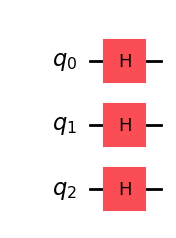

In [ ]:
from qiskit.quantum_info import Statevector
from IPython.display import display

def superposition_demo(n_qubits=3):
    qc = QuantumCircuit(n_qubits)

    # Apply Hadamard to all qubits
    for i in range(n_qubits):
        qc.h(i)

    # Get statevector
    state = Statevector.from_instruction(qc)

    print(f"Number of basis states = {2**n_qubits}\n")
    print("Statevector amplitudes:\n")
    display(state.draw("latex",decimals=3))

    return qc

# Example
qc = superposition_demo(3)
qc.draw("mpl")

<a id="chapter2"></a>
<h2 id="chapter2" style="color:#1F618D; font-weight:bold; font-size:26px; font-family:'Times New Roman', serif; border-bottom:2px solid #5DADE2; padding-bottom:6px;">
    📘 Chapter 2: Superdense Coding
</h2>


<p style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.7;">
    Superdense coding is a quantum communication protocol that allows the transmission of
    <b>two classical bits using a single qubit</b>, provided that the sender (Alice) and
    receiver (Bob) share one entangled pair (one <i>e-bit</i>).
</p>

<p style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.7;">
    This protocol is complementary to <b>quantum teleportation</b>:
</p>

<ul style="font-family:'Times New Roman', serif; font-size:15px;">
    <li>Teleportation $\Rightarrow$ 1 qubit using 2 classical bits</li>
    <li>Superdense coding $\Rightarrow$ 2 classical bits using 1 qubit</li>
</ul>

---

<h3 style="color:blue; font-family:'Times New Roman', serif; font-weight:bold">
    🔍 Analysis
</h3>

<p style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.7;">
    The key idea is that Alice transforms the shared entangled state into one of the
    four Bell states using local operations. Bob then identifies this state through measurement.
</p>
<p style="font-family:'Times New Roman', serif; font-size:16px;">
Starting from the shared Bell state:
</p>

<p style="text-align:center; font-size:18px;">
    $$|\phi^+\rangle = \frac{1}{\sqrt{2}} (|00\rangle + |11\rangle)$$
</p>

<p style="font-family:'Times New Roman', serif; font-size:16px;">
    Alice encodes classical bits <code>(cd)</code> as:
</p>

<p style="text-align:center; font-size:16px;">
    $(I \otimes I)|\phi^+\rangle = |\phi^+\rangle \quad \quad$
    $(I \otimes Z)|\phi^+\rangle = |\phi^-\rangle$ <br>
    $(I \otimes X)|\phi^+\rangle = |\psi^+\rangle \quad \quad$
    $(I \otimes XZ)|\phi^+\rangle = |\psi^-\rangle$
</p>

<p style="font-family:'Times New Roman', serif; font-size:16px;">
    Bob applies a decoding circuit (CNOT followed by Hadamard), mapping Bell states to classical states:
</p>

<p style="text-align:center; font-size:16px;">
    $$|\phi^+\rangle \rightarrow |00\rangle \quad |\phi^-\rangle \rightarrow |01\rangle$$
    $$|\psi^+\rangle \rightarrow |10\rangle \quad |\psi^-\rangle \rightarrow |11\rangle$$
</p>
<p style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.7;">
    Measuring the final state allows Bob to uniquely determine the classical bits
    <code>(cd)</code> sent by Alice.
</p>

<div style="text-align:center; margin:15px 0;">
    <img src="https://quantum.cloud.ibm.com/learning/images/courses/basics-of-quantum-information/entanglement-in-action/superdense-coding.svg"
    width="70%" style="border-radius:8px; box-shadow:0px 3px 8px rgba(0,0,0,0.1);">
    <p style="font-family:'Times New Roman', serif; font-size:15px; color:#566573; margin-top:8px; text-align:center">
        Figure: Superdense Coding Protocol
    </p>
</div>


<p style="font-family:'Times New Roman', serif; font-size:14px;;">
    💡 The global phase (− sign in $|\psi^-\rangle$) has no effect on measurement outcomes.
</p>

<h3 style="color:blue; font-family:'Times New Roman', serif; font-weight:bold">
    🔍 Qiskit Implementation
</h3>


In [ ]:
def superdense_coding(message="10", shots=1024):

    simulator = AerSimulator()

    qc = QuantumCircuit(2,2) # Quantum Circuit

    # Step 1: Create Bell pair
    qc.h(0)
    qc.cx(0,1)
    qc.barrier()

    # Step 2: Alice encodes message
    c, d = message  # c = first bit, d = second bit

    if d == "1":
        qc.z(0)
    if c == "1":
        qc.x(0)

    qc.barrier()

    # Step 3: Bob decodes
    qc.cx(0,1)
    qc.h(0)

    qc.barrier()

    # Step 4: Measurement
    qc.measure([0,1],[0,1])

    # Run simulation
    # tqc = transpile(qc, simulator)
    result = simulator.run(qc, shots=shots).result()
    counts = result.get_counts()

    return qc, counts

Measured 10 with frequency 1024


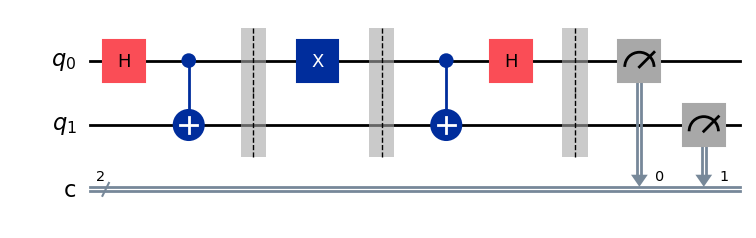

In [ ]:
qc, counts = superdense_coding("10")

# Print Measurements
for outcome, frequency in counts.items():
    print(f"Measured {outcome} with frequency {frequency}")

# Draw the Circuit
qc.draw("mpl")

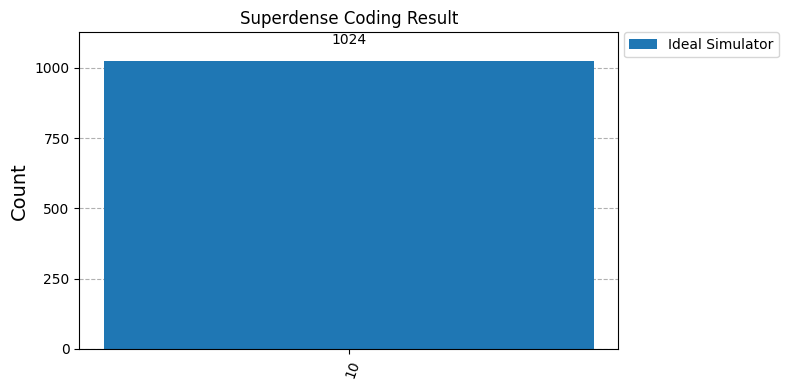

In [ ]:
plot_histogram(counts, figsize=(8,4), title="Superdense Coding Result", legend=["Ideal Simulator"])

<h3 style="color:#D35400; font-family:'Times New Roman', serif; font-weight:bold">
    📝 Home Task
</h3>

<p style="font-family:'Times New Roman', serif; font-size:16px;">
    Extend the superdense coding simulation by incorporating <b>noise effects</b>.
</p>

<ul style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.8;">
    <li>Implement a <b>noisy simulator</b> using a depolarizing noise model</li>
    <li>Compare results with the ideal simulator</li>
    <li>Plot both distributions on the same histogram</li>
</ul>

<p style="font-family:'Times New Roman', serif; font-size:16px;">
    Analyze how noise affects the reliability of transmitted information.
</p>

---

<p style="font-family:'Times New Roman', serif; font-size:15px;">
    💡 <b style="color:blue">Hint:</b> Use <code>NoiseModel</code> and <code>depolarizing_error</code> from Qiskit Aer.
</p>

<p style="font-family:'Times New Roman', serif; font-size:15px;">
    🎯 <b style="color:red">Goal:</b> Understand the impact of noise on quantum communication protocols.
</p>

<a id="chapter3"></a>
<h2 id="chapter3" style="color:#1F618D; font-weight:bold; font-size:26px; font-family:'Times New Roman', serif; border-bottom:2px solid #5DADE2; padding-bottom:6px;">
    📘 Chapter 3: Quantum Teleportation
</h2>


<p style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.7;">
    Quantum teleportation is a protocol that allows the transfer of an
    <b>unknown quantum state</b> from one location (Alice) to another (Bob)
    using <b>entanglement and classical communication</b>, without physically sending the qubit itself.
</p>

---
<h3 style="color:#117A65; font-family:'Times New Roman', serif; font-weight:bold">
    🔍 Analysis
</h3>

<p style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.7;">
    The key idea of teleportation is that Alice transfers the state of her qubit onto Bob’s qubit using entanglement and measurement. The original state is destroyed at Alice’s side and reconstructed at Bob’s side.
</p>

<p style="font-family:'Times New Roman', serif; font-size:16px;">
    Let the unknown state be:
</p>

<p style="text-align:center; font-size:18px;">
    $$|\psi\rangle = \alpha |0\rangle + \beta |1\rangle$$
</p>

<p style="font-family:'Times New Roman', serif; font-size:16px;">
    Alice and Bob share a Bell pair:
</p>

<p style="text-align:center; font-size:18px;">
    $$|\phi^+\rangle = \frac{1}{\sqrt{2}} (|00\rangle + |11\rangle)$$
</p>

<p style="font-family:'Times New Roman', serif; font-size:16px;">
    The teleportation protocol proceeds as follows:
</p>

<ol style="font-family:'Times New Roman', serif; font-size:15px; line-height:1.8;">
    <li>Alice entangles her qubit with her part of the Bell pair (CNOT + H)</li>
    <li>Alice measures her two qubits → obtains classical bits <code>(c, d)</code></li>
    <li>Alice sends these 2 classical bits to Bob</li>
    <li>Bob applies correction operations based on <code>(c, d)</code></li>
</ol>


<table style="width:50%; border-collapse:collapse; font-family:'Times New Roman', serif; font-size:15px; margin:auto;">
<tr style="background-color:#D6EAF8;">
    <th style="padding:6px;">(cd)</th>
    <th style="padding:6px;">Bob’s Operation</th>
</tr>

<tr><td style="padding:6px; text-align:center;">00</td><td style="text-align:center;">I</td></tr>
<tr><td style="padding:6px; text-align:center;">01</td><td style="text-align:center;">X</td></tr>
<tr><td style="padding:6px; text-align:center;">10</td><td style="text-align:center;">Z</td></tr>
<tr><td style="padding:6px; text-align:center;">11</td><td style="text-align:center;">XZ</td></tr>
</table>


<p style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.7;">
    After applying the correct operation, Bob recovers the original state
    $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$.
</p>


<div style="text-align:center; margin:15px 0;">
    <img src="https://quantum.cloud.ibm.com/learning/images/courses/basics-of-quantum-information/entanglement-in-action/teleportation.svg"
    width="70%" style="border-radius:8px; box-shadow:0px 3px 8px rgba(0,0,0,0.1);">
    <p style="font-family:'Times New Roman', serif; font-size:16px; color:#566573; margin-top:8px; text-align:center">
        Figure: Quantum Teleportation Protocol
    </p>
</div>


<p style="font-family:'Times New Roman', serif; font-size:14px; color:#566573;">
    💡 The original quantum state is destroyed during measurement — this ensures
    consistency with the <b>no-cloning theorem</b>.
</p>

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import random

def quantum_teleportation(theta, phi, lam, shots=1024):

    simulator = AerSimulator()

    # Registers
    qubit = QuantumRegister(1, "ψ")   # State to teleport
    ebit0 = QuantumRegister(1, "A")   # Alice
    ebit1 = QuantumRegister(1, "B")   # Bob
    a = ClassicalRegister(1, "c")
    b = ClassicalRegister(1, "d")
    res = ClassicalRegister(1, "res")
    # Quantum Circuit
    qc = QuantumCircuit(qubit, ebit0, ebit1, a, b, res)

    # Step 1: Prepare state to teleport
    qc.u(theta, phi, lam, 0)
    qc.barrier()

    # Step 2: Entanglement (Bell Pair)
    qc.h(ebit0)
    qc.cx(ebit0, ebit1)
    qc.barrier(label="Bell Pair")

    # Step 3: Alice Operations -----------
    qc.cx(qubit, ebit0)
    qc.h(qubit)
    qc.barrier(label="Alice Ops")

    # Step 4: Measurement
    qc.measure(ebit0, a)
    qc.measure(qubit, b)
    qc.barrier(label="Measurement")

    # Step 5: Bob Correction
    with qc.if_test((a, 1)):
        qc.x(ebit1)
    with qc.if_test((b, 1)):
        qc.z(ebit1)
    qc.barrier(label="Bob Correction")


    # Step 6A:

    # Step 6B: Measure Bob's qubit
    qc.measure(ebit1, res)

    # Run simulation
    result = simulator.run(qc, shots=shots).result()
    counts = result.get_counts()

    return qc, counts

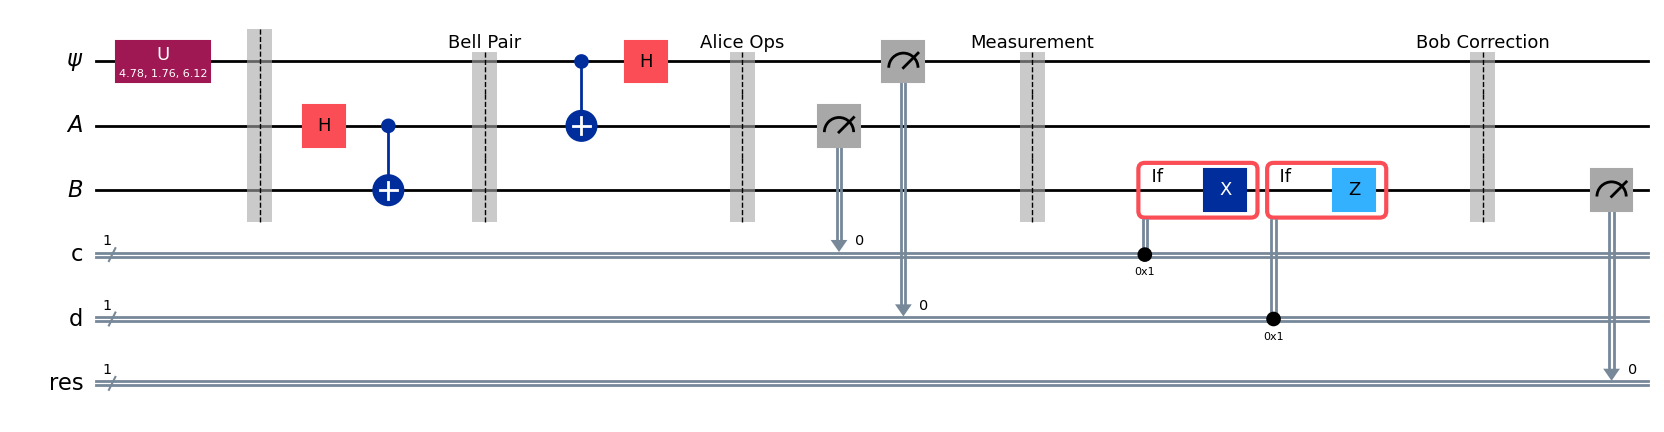

In [ ]:
t = 2*pi*np.random.random(3)
qc, counts = quantum_teleportation(t[0],t[1],t[2])

# U-gate representation           # Gate equivalent     # State produced from |0>
#qc.u(np.pi, 0, np.pi, 0)          # X gate               # |1>
#qc.u(np.pi/2, 0, np.pi, 0)        # Hadamard gate        # |+> = (|0> + |1>)/√2
#qc.u(np.pi/2, np.pi, np.pi, 0)    # -|-> (global phase)  # |-> = (|0> - |1>)/√2

# Draw the circuit
qc.draw("mpl", fold=-1)

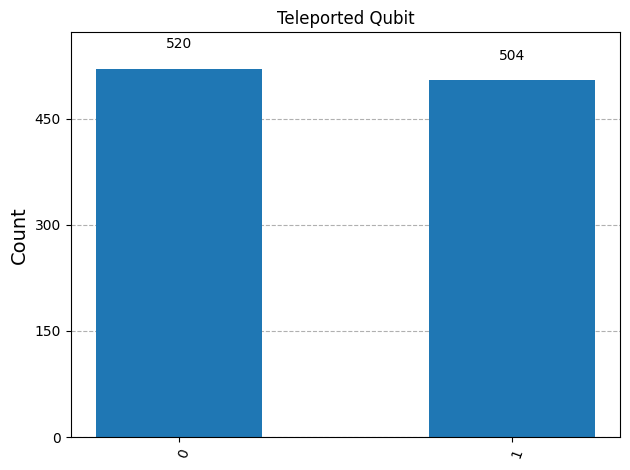

In [ ]:
from qiskit.result import marginal_counts
# keep only the 3rd qubit (classical bit index 2) as first 2 qubits measurements gives no information
counts_tele = marginal_counts(counts, indices=[2])

# plot_histogram(counts,title="Full Measurement Results (Teleportation)",bar_labels=True)
plot_histogram(counts_tele, title="Teleported Qubit")

<h3 style="color:#D35400; font-family:'Times New Roman', serif; font-weight:bold">
    📝 Home Task
</h3>

<p style="font-family:'Times New Roman', serif; font-size:16px;">
    Extend the Quantum Teleportation simulation by incorporating <b>noise effects</b>.
</p>

<ul style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.8;">
    <li>Implement a <b>noisy simulator</b> using a depolarizing noise model</li>
    <li>Compare results with the ideal simulator</li>
    <li>Plot both distributions on the same histogram</li>
</ul>

<p style="font-family:'Times New Roman', serif; font-size:16px;">
    Analyze how noise affects the reliability of transmitted information.
</p>

---

<p style="font-family:'Times New Roman', serif; font-size:15px;">
    💡 <b style="color:blue">Hint:</b> Use <code>NoiseModel</code> and <code>depolarizing_error</code> from Qiskit Aer.
</p>

<p style="font-family:'Times New Roman', serif; font-size:15px;">
    🎯 <b style="color:red">Goal:</b> Understand the impact of noise on quantum communication protocols.
</p>

In [ ]:
import pkg_resources
import platform

print("🔹 Installed Qiskit-related Packages\n")

for pkg in sorted(pkg_resources.working_set, key=lambda x: x.project_name.lower()):
    if "qiskit" in pkg.project_name.lower():
        print(f"{pkg.project_name} == {pkg.version}")

print("\n🔹 System Info")
print("Python:", platform.python_version())
print("OS:", platform.system(), platform.release())

🔹 Installed Qiskit-related Packages

qiskit == 2.3.0
qiskit-aer == 0.17.2
qiskit-algorithms == 0.4.0
qiskit-code-assistant-jupyterlab == 0.10.0
qiskit-ibm-runtime == 0.45.0
qiskit-nature == 0.7.2

🔹 System Info
Python: 3.11.8
OS: Darwin 24.6.0


<hr>
<p style="text-align:center; font-family:'Times New Roman', serif; font-size:13px; color:#5D6D7E;">
    ⚛️ Atomic, Molecular and Quantum Information (AMQI) Group <br>
    Department of Physics • Quantum Computing Notebook <br>
    Built using Qiskit Framework
</p>